##### Im ersten Schritt wandeln wir Text in Features um. Modelle können keinen Text verstehen, deshalb brauchen wir numerische Features. Hierzu nutzen wir die TF-IDF Methode. Diese gilt als Standard für Sentiment.

In [67]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

#Man kann hier zusätzlich auch die Auswirkung auf das Modell der anderen Datesätze untersuchen (Ohne Bigram).
df= pd.read_csv("../data/BMW/bigram_preprocessed_reviews.csv")
#Nach einigen Preprocessing operationen sind 11 NaN-Werte in der Spalte "lemmatized_text". 
#TF-IDF kann kein NaN Wert verarbeiten, deswegen entfernen wir diese Zeilen.
df=df.dropna(subset=["lemmatized_text"])

In [68]:
df.isna().sum()

reviewId                  0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    555
at                        0
appVersion              555
company                   0
clean_text                0
tokens                    0
lemmatized_text           0
tokens_bigram             0
final_text                0
dtype: int64

##### Einige Reviews enthalten keine Informationen über die verwendete App-Version. Da Versionsinformationen für die Sentiment-klassifikation nicht erforderlich sind, wurden diese Reviews im Datensatz beibehalten. Diese sollten nur für Analysen wie (Rating pro Version, Update Impact und Version Comparison) bereinigt werden.

##### Im nächsten Schritt definieren wir die Target Variablen, also Sentiment aus dem Rating.

In [69]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"
    
df["sentiment"] = df["score"].apply(sentiment_label)

In [70]:
#Hier machen wir TF-IDF Vektorisierung.
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X= vectorizer.fit_transform(df["lemmatized_text"])
y= df["sentiment"]

##### Anschließend machen wir den Train/Test Split

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, df["sentiment"], test_size=0.2, random_state=42)

##### Nun erstellen wir unser erstes Modell. Wir beginnen mit LogisticRegression.

In [72]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [73]:
# sehen wie viele Itertionen gebraucht wurden
print(log_model.n_iter_)

[84]


In [74]:
# Wir erstellen hier die Prediction für das Logistic Regression Modell (Evaluation)
from sklearn.metrics import classification_report
y_pred_log = model.predict(X_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

    negative       0.76      0.87      0.81       849
     neutral       0.44      0.02      0.04       178
    positive       0.85      0.89      0.87      1073

    accuracy                           0.81      2100
   macro avg       0.69      0.59      0.57      2100
weighted avg       0.78      0.81      0.78      2100



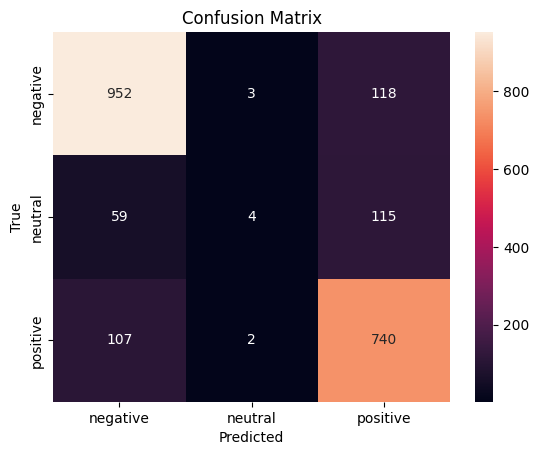

In [75]:
# Hier erstellen wir die Confusion Matrix für das Logistic Regression Modell
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm= confusion_matrix(y_test, y_pred_log, labels=["positive", "neutral", "negative"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##### Interpretation Confusion Matrix Linear Regression Modell
- Zeilen = echte Labels (True)
- Spalten = Modellvorhersage (Predicted)

- Echte negative Reviews: 952+3+118=1073 --> Davon korrekt erkannt: 952, als positiv klassifiziert = 118, als neutral klassifiziert = 3
- Interpretation: Das Modell erkennt negative Reviews sehr gut, aber manchmal werden negative Reviews als positiv interpretiert.
Das passiert oft bei Sätzen wie: Great app but crashes sometimes.
- Echte neutrale reviews: 59+4+115=178 --> Davon korrekt erkannt: 4
- Interpretation: Das Modell erkennt Neutralität sehr schlecht. Das ist normal bei Sentiment-Modellen, weil neutrale Reviews oft schwer zu unterscheiden sind.
- Echte positive Reviews: 107+2+740=849 -->Davon korrekt erkannt: 740, als negativ klassifizeirt: 107, als neutral klassifiziert: 2
- Interpretation: Das Modell erkennt positive Reviews sehr gut.
- Gesamtinterpretation: Das Modell ist gut bei positive, negative aber schlecht bei neutral. Das ist sehr typisch für Sentimentanalyse. Viele Studien machen deshalb nur negative vs positive.
- Unser Modell ist mit einer accuracy von fast 80% sehr solide.

##### Zum Vergleich testen wir noch das Linear SVM Modell.

In [76]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train, y_train)


LinearSVC(max_iter=5000)

In [77]:
# sehen wie viele Itertionen gebraucht wurden
print(svm_model.n_iter_)

48


In [78]:
# Wir erstellen hier die Prediction für das SVM Modell und den Classification Report (Evaluation)
from sklearn.metrics import classification_report
y_pred_svm= svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

    negative       0.77      0.84      0.80       849
     neutral       0.29      0.10      0.15       178
    positive       0.85      0.88      0.87      1073

    accuracy                           0.80      2100
   macro avg       0.64      0.61      0.61      2100
weighted avg       0.77      0.80      0.78      2100



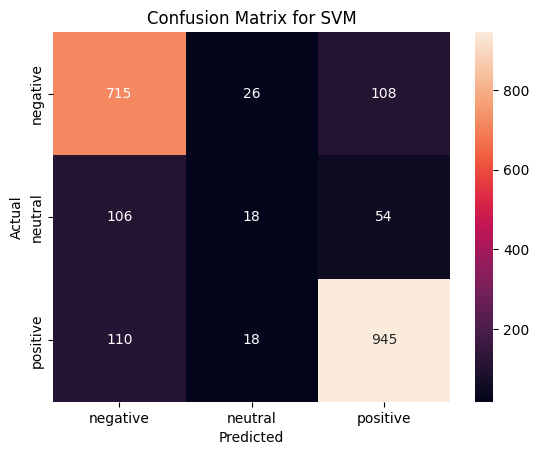

In [79]:
# Hier erstellen wir die Confusion Matrix für das SVM Modell
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm= confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()

##### Interpretation Confusion Matrix SVM Modell


In [80]:
# Hier vergleichen wir die accuracy der beiden Modelle
from sklearn.metrics import accuracy_score
print("Logistic Regression Classification Report:",accuracy_score(y_test, y_pred_log))
print("SVM Classification Report:",accuracy_score(y_test, y_pred_svm))

Logistic Regression Classification Report: 0.8076190476190476
SVM Classification Report: 0.799047619047619


##### Nachfolgend ermitteln wir mithilfe von GridsearchCV die besten Hyperparameter für unsere Modelle

In [86]:
#GridSearchCV für Logistic Regression Modell
from sklearn.model_selection import GridSearchCV

param_grid_log= {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}
grid_log= GridSearchCV(LogisticRegression(max_iter=1000,class_weight="balanced"), param_grid_log, cv=5, scoring="accuracy")
grid_log.fit(X_train, y_train)
print("Best Parameters for Logistic Regression:", grid_log.best_params_)
print("Best Score for Logistic Regression:", grid_log.best_score_)

Best Parameters for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.7905461017045294


In [88]:
#Wir evaluieren anschließend das Logistic Regression Modell mit den besten Hyperparametern
best_log_model = grid_log.best_estimator_
y_pred_best_log = best_log_model.predict(X_test)
print(classification_report(y_test, y_pred_best_log))

              precision    recall  f1-score   support

    negative       0.76      0.85      0.80       849
     neutral       0.28      0.16      0.20       178
    positive       0.87      0.86      0.86      1073

    accuracy                           0.79      2100
   macro avg       0.64      0.62      0.62      2100
weighted avg       0.78      0.79      0.78      2100



In [90]:
#GridSearchCV für SVM Modell
param_grid_svm= {
    "C": [0.01, 0.1, 1, 10]}
grid_svm= GridSearchCV(LinearSVC(class_weight="balanced",max_iter=5000), param_grid_svm, cv=5, scoring="accuracy")
grid_svm.fit(X_train, y_train)
print("Best Parameters for SVM:", grid_svm.best_params_)
print("Best Score for SVM:", grid_svm.best_score_)

Best Parameters for SVM: {'C': 0.1}
Best Score for SVM: 0.7917363651833575


In [91]:
#Wir evaluieren anschließend das SVM Modell mit den besten Hyperparametern
best_svm_model = grid_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test)
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

    negative       0.76      0.86      0.81       849
     neutral       0.30      0.16      0.21       178
    positive       0.88      0.85      0.86      1073

    accuracy                           0.80      2100
   macro avg       0.65      0.62      0.63      2100
weighted avg       0.78      0.80      0.79      2100



##### Modellvergleich und Auswahl des finalen Modells
Sowohl Logistic Regression als auch Linear SVM erzielten eine sehr ähnliche Leistung mit einer Genauigkeit von etwas 80%. Allerdings schnitt das Linear-SVM-Modell leicht besser ab als die Logistic Regression. Aus diesem Grund wurde Linear SVM als finales Modell für die Sentimentklassifikation ausgewählt.

Nachfolgend schauen wir uns die wichtigsten Wörter im Modell an.

In [92]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_
for i, label in enumerate(model.classes_):
    top10 = coefficients[i].argsort()[-10:]
    print(f"Top 10 words for {label}:")
    for j in top10:
        print(feature_names[j])

Top 10 words for negative:
mal
unbrauchbar
bad
schrott
not
ständig
schlecht
mehr
poor
useless
Top 10 words for neutral:
sometimes
leider
pin
ok
verbrauch
warum
km
however
miss
fehlen
Top 10 words for positive:
übersichtlich
tolle
zufrieden
useful
excellent
top
gut
easy
super
great


In [93]:
#Hier speichern wir das Dataset Sentiment Notebook
df.to_csv("../data/BMW/sentiment_preprocessed_reviews.csv", index=False)